In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_selection import f_regression
from sklearn.preprocessing import StandardScaler,LabelEncoder,OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.linear_model import LassoCV,RidgeCV

In [2]:
Data = pd.read_csv('ToyotaCorolla - MLR.csv')
Data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
Data.shape

(1436, 11)

In [4]:
Data.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [5]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


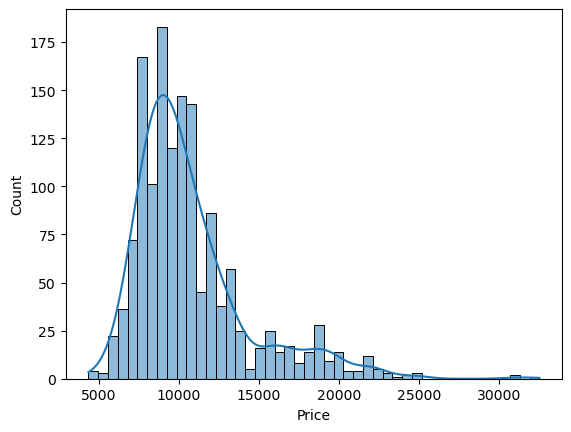

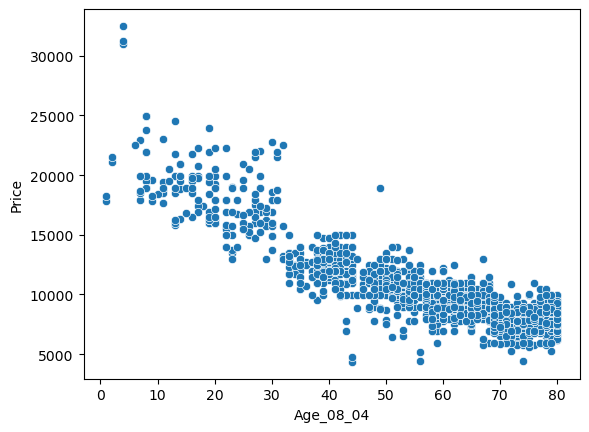

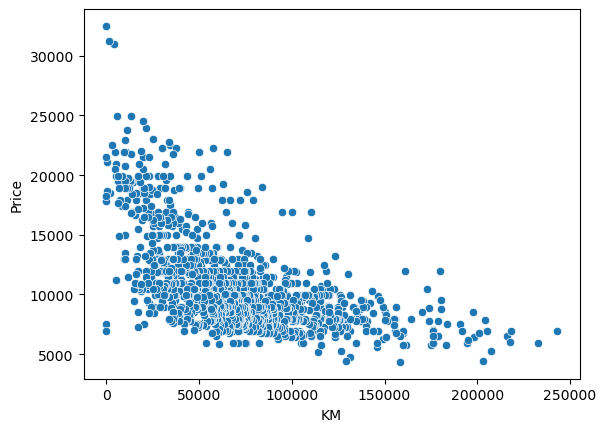

In [6]:
sns.histplot(Data['Price'], kde=True)
plt.show()

sns.scatterplot(x='Age_08_04', y='Price', data=Data)
plt.show()

sns.scatterplot(x='KM', y='Price', data=Data)
plt.show()

In [7]:
## Checking Missing Values
Data.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [8]:
## Checking Duplicated Values
Data.duplicated().sum()

np.int64(1)

In [9]:
Data.drop_duplicates(inplace=True,ignore_index=True)

In [10]:
Data.duplicated().sum()

np.int64(0)

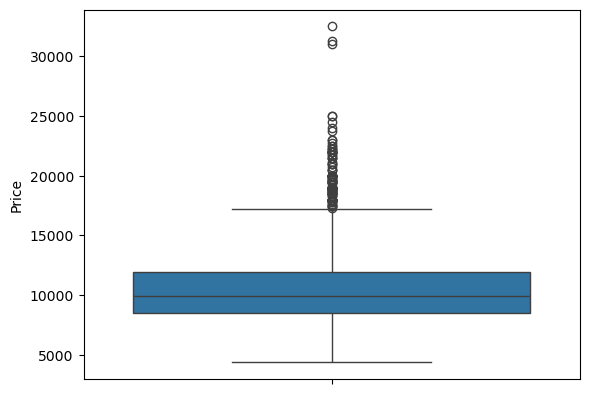

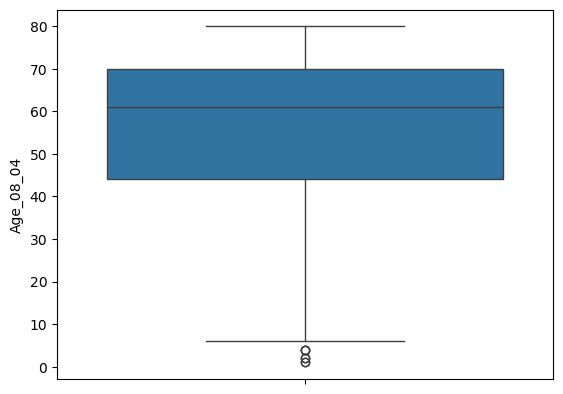

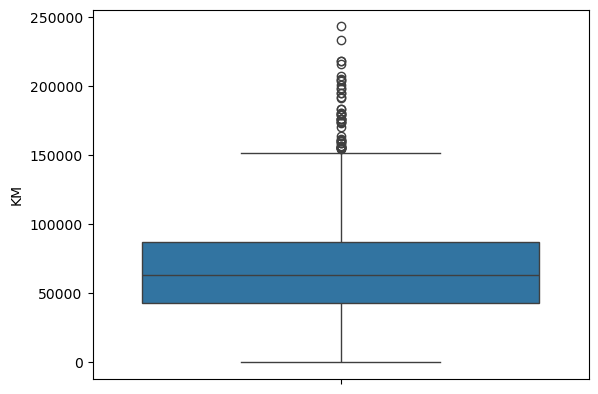

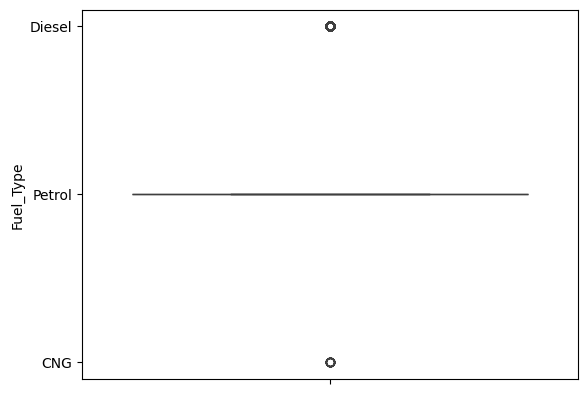

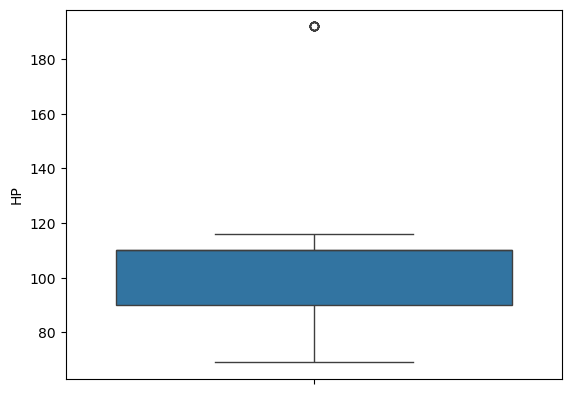

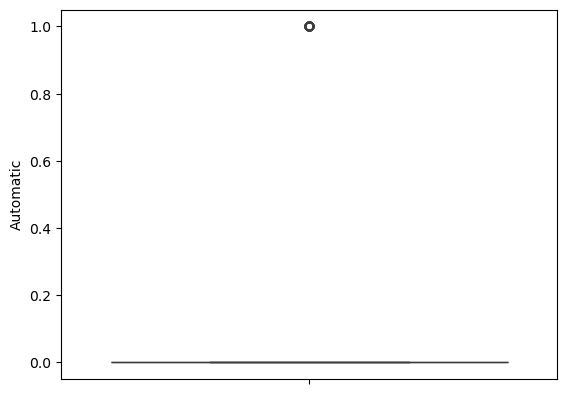

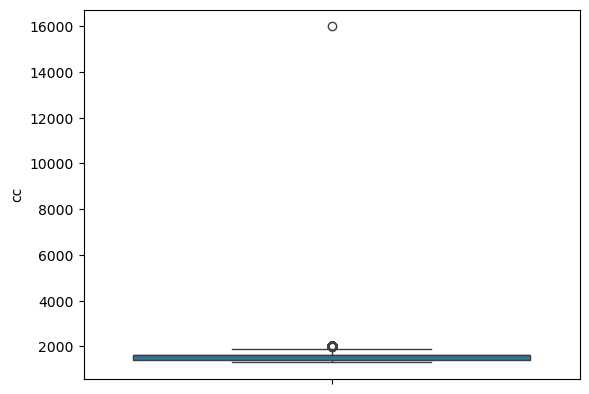

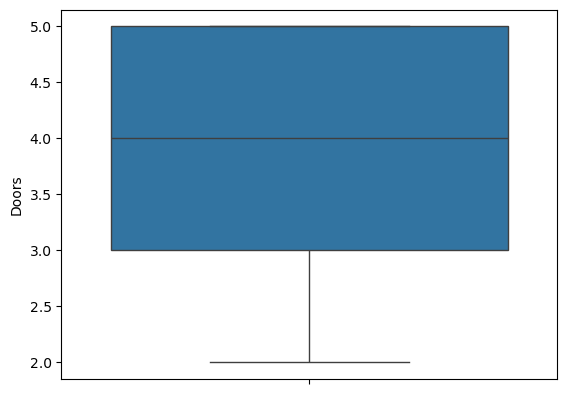

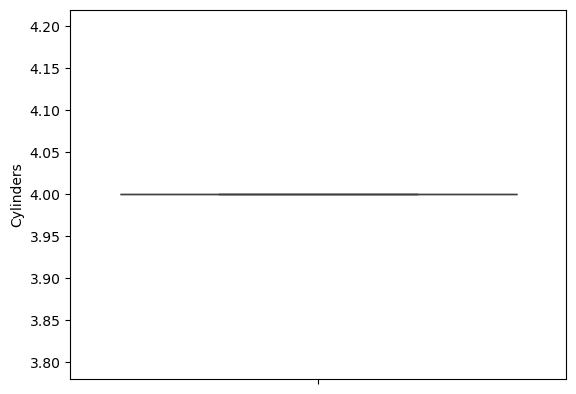

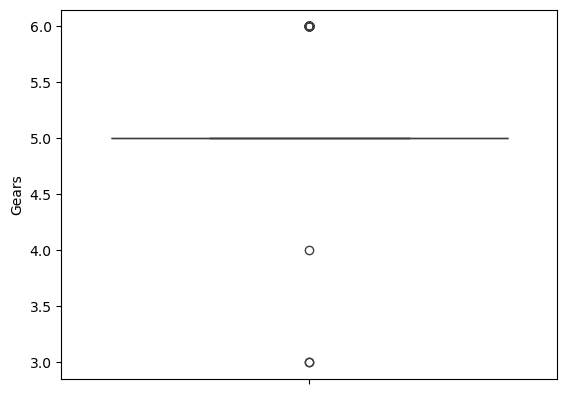

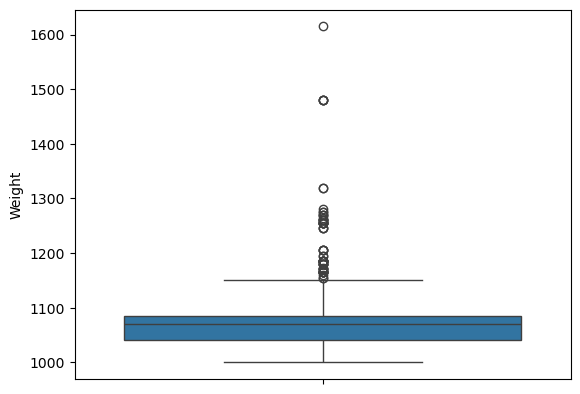

In [11]:
## Checking Outliers
for col in Data.columns:
    sns.boxplot(data = Data,y=col)
    plt.show()

In [12]:
### outlier capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3= df[columns].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[columns]= df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in Data.select_dtypes(include=['int','float']).columns:
    outlier_capping(Data,col)

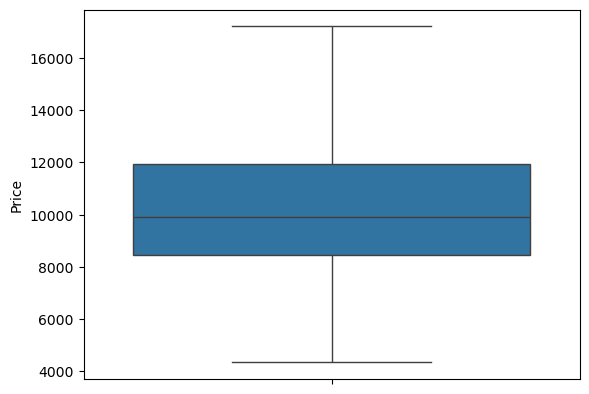

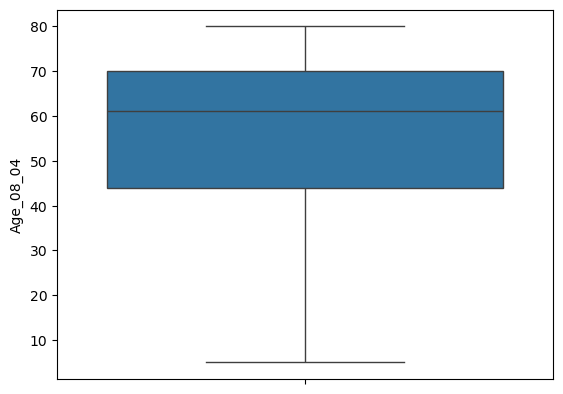

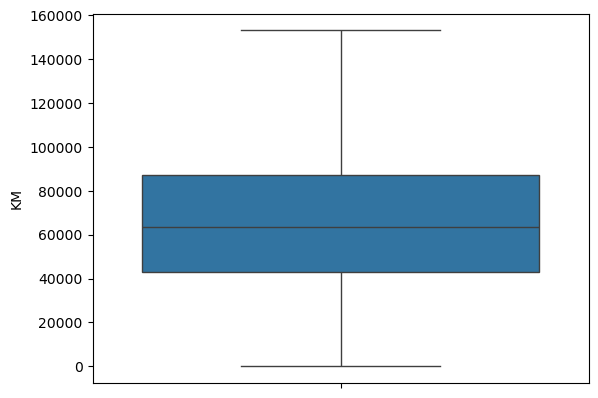

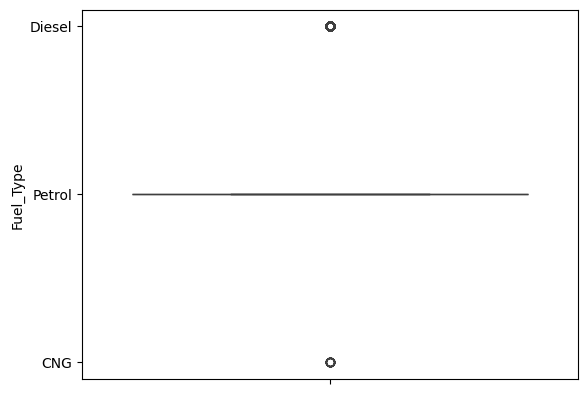

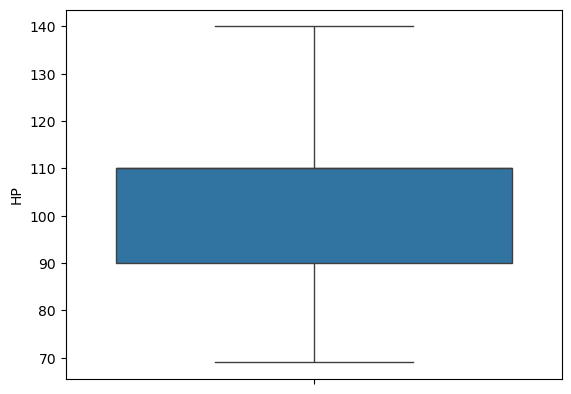

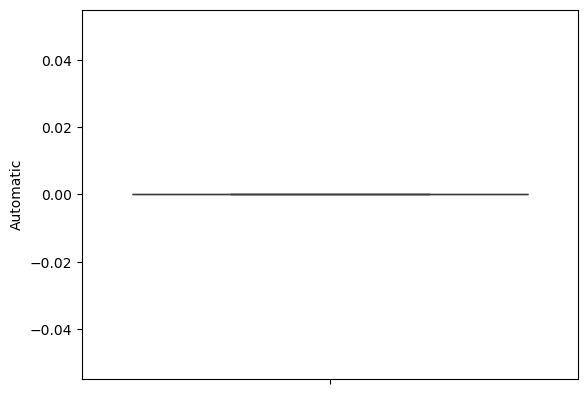

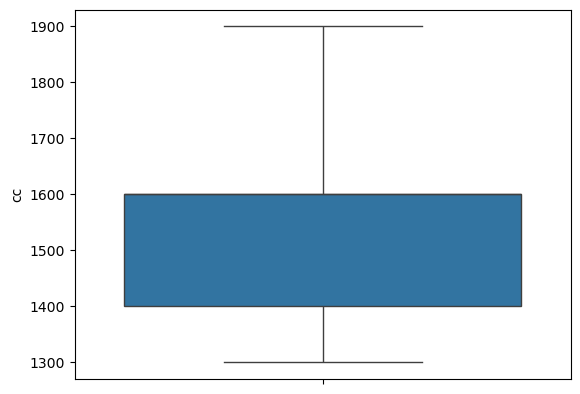

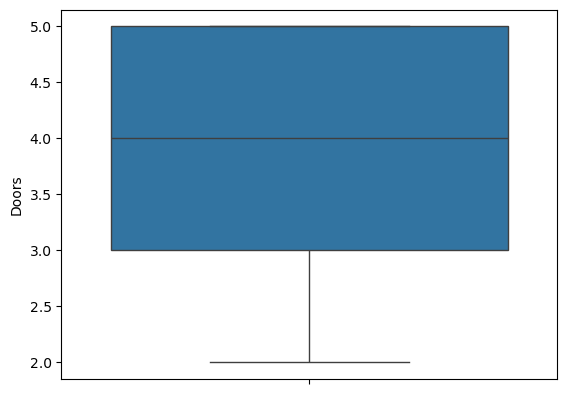

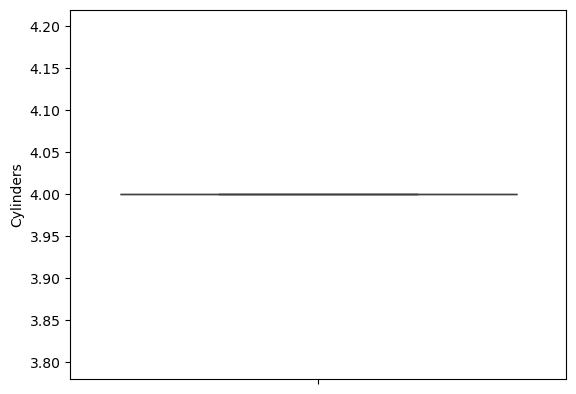

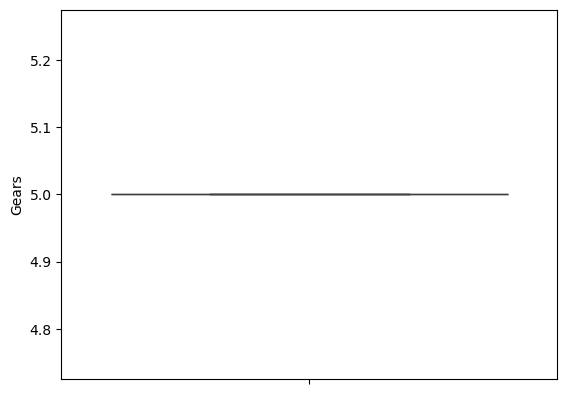

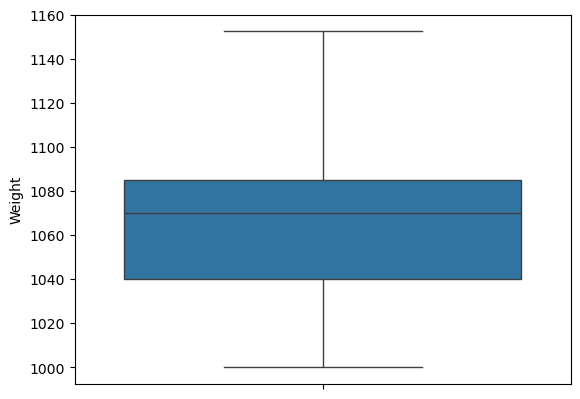

In [13]:
for col in Data.columns:
    sns.boxplot(data = Data,y=col)
    plt.show()

In [14]:
target=Data[['Price']]
features=Data.drop(columns=['Price'])
features.head()

,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,23.0,46986.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
1,23.0,72937.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
2,24.0,41711.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
3,26.0,48000.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
4,30.0,38500.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5


In [15]:
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1148, 10)
(287, 10)
(1148, 1)
(287, 1)


In [16]:
num_cols = [i for i in features.columns if Data[i].dtype != 'object']
cat_cols = [i for i in features.columns if Data[i].dtype == 'object']
print(num_cols)
print(cat_cols)

['Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight']
['Fuel_Type']


In [17]:
features[num_cols].head()

,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,23.0,46986.0,90.0,0.0,1900.0,3,4,5.0,1152.5
1,23.0,72937.0,90.0,0.0,1900.0,3,4,5.0,1152.5
2,24.0,41711.0,90.0,0.0,1900.0,3,4,5.0,1152.5
3,26.0,48000.0,90.0,0.0,1900.0,3,4,5.0,1152.5
4,30.0,38500.0,90.0,0.0,1900.0,3,4,5.0,1152.5


In [18]:
std_sca= StandardScaler()
x_train[['Age_08_04','KM','HP','cc','Weight']] = std_sca.fit_transform(x_train[['Age_08_04','KM','HP','cc','Weight']])
x_test[['Age_08_04','KM','HP','cc','Weight']] = std_sca.transform(x_test[['Age_08_04','KM','HP','cc','Weight']])

In [19]:
x_train.head()

,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
108,-1.940533,-1.748188,Petrol,0.689004,0.0,0.255237,3,4,5.0,0.954608
1279,1.182405,0.176456,Petrol,-1.123604,0.0,-1.492799,4,4,5.0,-1.387370
857,0.320905,-0.079609,Petrol,0.689004,0.0,0.255237,5,4,5.0,0.173948
902,0.482436,-0.247509,Petrol,0.689004,0.0,0.255237,5,4,5.0,0.173948
372,-1.240564,-1.478104,Petrol,-0.292825,0.0,-0.910121,5,4,5.0,0.434168


In [20]:
ord_enc = OrdinalEncoder()
x_train[['Fuel_Type']] = ord_enc.fit_transform(x_train[['Fuel_Type']])
x_test[['Fuel_Type']] = ord_enc.transform(x_test[['Fuel_Type']])

In [21]:
x_train.head()

,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
108,-1.940533,-1.748188,2.0,0.689004,0.0,0.255237,3,4,5.0,0.954608
1279,1.182405,0.176456,2.0,-1.123604,0.0,-1.492799,4,4,5.0,-1.387370
857,0.320905,-0.079609,2.0,0.689004,0.0,0.255237,5,4,5.0,0.173948
902,0.482436,-0.247509,2.0,0.689004,0.0,0.255237,5,4,5.0,0.173948
372,-1.240564,-1.478104,2.0,-0.292825,0.0,-0.910121,5,4,5.0,0.434168


In [22]:
f_reg = f_regression(x_train,y_train)
pd.Series(f_reg[0],index=x_train.columns).sort_values(ascending=False)

Age_08_04    4682.022093
KM            652.535829
Weight        462.397253
HP             80.117047
Doors          51.248273
cc             28.813235
Fuel_Type       0.030577
Automatic       0.000000
Cylinders       0.000000
Gears           0.000000
dtype: float64

In [23]:
x_train.drop(columns=['Automatic','Cylinders','Gears'],inplace=True)
x_test.drop(columns=['Automatic','Cylinders','Gears'],inplace=True)

In [24]:
x_train.head()

,Age_08_04,KM,Fuel_Type,HP,cc,Doors,Weight
108,-1.940533,-1.748188,2.0,0.689004,0.255237,3,0.954608
1279,1.182405,0.176456,2.0,-1.123604,-1.492799,4,-1.387370
857,0.320905,-0.079609,2.0,0.689004,0.255237,5,0.173948
902,0.482436,-0.247509,2.0,0.689004,0.255237,5,0.173948
372,-1.240564,-1.478104,2.0,-0.292825,-0.910121,5,0.434168


### Model Building 1

In [25]:
lin_reg1 = LinearRegression()
lin_reg1.fit(x_train,y_train)

LinearRegression()

In [26]:
b0 = lin_reg1.coef_
b0

array([[-1964.75367672,  -518.5375997 ,   505.19447052,   264.40987996,
         -336.0687773 ,   -94.80588066,   988.52399898]])

In [27]:
b1 = lin_reg1.intercept_
b1

array([9927.27492371])

In [28]:
## Training Accuracy
y_pred1 = lin_reg1.predict(x_train)
r2_score(y_train,y_pred1)

0.8689916567072791

In [29]:
## Testing Accuracy
y_pred1=lin_reg1.predict(x_test)
print("r2_score:",r2_score(y_test,y_pred1))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred1)))

r2_score: 0.8502399214923703
RMSE: 1126.5069402196677


### Model Building 2 

In [30]:
selected_cols = ['Age_08_04','KM','HP','Weight','Doors','cc']

In [31]:
lin_reg2=LinearRegression()
lin_reg2.fit(x_train[selected_cols],y_train)

LinearRegression()

In [32]:
b0 = lin_reg2.coef_
b0

array([[-1955.52418769,  -545.84661718,   350.62461892,   946.39289947,
          -81.65641464,  -421.70274935]])

In [33]:
b1 = lin_reg2.intercept_
b1

array([10817.42681117])

In [34]:
## Training accuracy
y_pred2 = lin_reg2.predict(x_train[selected_cols])
r2_score(y_train,y_pred2)

0.8675985105652546

In [35]:
## Testing Accuracy
y_pred2=lin_reg2.predict(x_test[selected_cols])
print("r2_score:",r2_score(y_test,y_pred2))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred2)))

r2_score: 0.8473627877706413
RMSE: 1137.2764728896511


### Model Building 3

In [36]:
top_cols = ['Age_08_04','KM','Weight']

In [37]:
lin_reg3=LinearRegression()
lin_reg3.fit(x_train[top_cols],y_train)

LinearRegression()

In [38]:
b0=lin_reg3.coef_
b0

array([[-1967.32142157,  -758.80540846,   623.39160079]])

In [39]:
b1=lin_reg3.intercept_
b1

array([10488.88066202])

In [40]:
## Training accuracy
y_pred3=lin_reg3.predict(x_train[top_cols])
r2_score(y_train,y_pred3)

0.8536223663894826

In [41]:
## Testing accuracy
y_pred3=lin_reg3.predict(x_test[top_cols])
print("r2_score:",r2_score(y_test,y_pred3))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred3)))

r2_score: 0.8351036244654845
RMSE: 1182.0651052343078


In [42]:
y_pred1=lin_reg1.predict(x_test)

In [43]:
r2 = r2_score(y_test, y_pred1)
mse = mean_squared_error(y_test, y_pred1)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred1)

In [44]:
print("r2:",r2)
print("mse:",mse)
print("rmse:",rmse)
print("mae:",mae)

r2: 0.8502399214923703
mse: 1269017.8863630781
rmse: 1126.5069402196677
mae: 829.7133175476062


In [45]:
## Apply Lasso

In [46]:
lassocv=LassoCV(cv=5)
lassocv.fit(x_train,y_train)
y_pred_lasso=lassocv.predict(x_test)
r2_score(y_test,y_pred_lasso)

0.8501714405462473

In [47]:
print(f"Best Alpha: {lassocv.alpha_}")
print(f"R² Score: {r2_score(y_test, y_pred_lasso):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.2f}")

Best Alpha: 2.6823695736236655
R² Score: 0.8502
RMSE: 1126.76


In [48]:
## Apply Ridge

In [49]:
ridgecv=RidgeCV(alphas=(0.1,1.0,10.0,2.4,5),cv=5)
ridgecv.fit(x_train,y_train)
y_pred_ridge=ridgecv.predict(x_test)
r2_score(y_test,y_pred_ridge)

0.850033270565109

In [50]:
ridgecv.alpha_

np.float64(5.0)

In [51]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"{model_name}")
    print("R² Score:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("-"*40)

In [52]:
evaluate_model(y_test, y_pred1, "Linear Regression")
evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
evaluate_model(y_test, y_pred_lasso, "Lasso Regression")

Linear Regression
R² Score: 0.8502399214923703
MAE: 829.7133175476062
RMSE: 1126.5069402196677
----------------------------------------
Ridge Regression
R² Score: 0.850033270565109
MAE: 829.6770794706821
RMSE: 1127.2838944473917
----------------------------------------
Lasso Regression
R² Score: 0.8501714405462473
MAE: 829.0972536924917
RMSE: 1126.764470280101
----------------------------------------


### Interview Question

Q-1 What is Normalization & Standardization?

Normalization :
Scales values to 0–1 range
Used in distance-based models

Standardization
Mean = 0, Std = 1
Essential for Linear, Ridge & Lasso Regression

Q-2 How to Handle Multicollinearity?

Multicollinearity Handling Methods:
1. Detection:
 - Correlation Matrix (correlation > 0.8)
 - Variance Inflation Factor (VIF > 10)

2. Solutions Implemented:
  - Feature elimination (removed constant features like Cylinders)
  - Reduced feature model (removed 'cc' due to high VIF)
  - Ridge Regression (shrinks correlated coefficients)#    - PCA (dimensionality reduction)
  - Lasso Regression (eliminates less important features)# 3. Alternative:

SUMMARY OF FINDINGS:

1. Data Preprocessing:
  - Identified and removed constant features (Cylinders)
  - Handled categorical variables (Fuel_Type) with one-hot encoding

2. Multicollinearity Analysis:

  - Calculated VIF to identify highly correlated features#    - Improved model performance compared to fixed alpha values
  - 'cc' showed high VIF and was removed in reduced model#    - Optimal Lasso alpha found through LassoCV
  - Addressed through feature selection and regularization#    - Optimal Ridge alpha found through RidgeCV

5. Hyperparameter Tuning:

3. Model Performance:

   - All models achieved good R² scores#    - KM: Negative impact on price
   - Ridge Regression (optimal α) provides stability with multicollinearity#    - HP: Positive impact on price
   - Lasso Regression (optimal α) performs automatic feature selection#    - Weight: Positive impact on price
   - Reduced feature model maintains performance with fewer features#    - Age_08_04: Strong negative impact on price

4. Key Predictors (from coefficient analysis):